# ==================================================
# Task 1: Data Acquisition & Initial Inspection
# ==================================================


## Load the dataset into a pandas DataFrame using pd.read_csv() (or equivalent). Print the first five rows, the column data types (.dtypes), and the DataFrame shape.



In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/laptopData.csv")

# Keep a copy of the original dataset
df_original = df.copy()

In [2]:
# First 5 Rows
print("First 5 Rows: -")
display(df.head(5))

First 5 Rows: -


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [3]:
# Data Types
print("Data Types: -")
display(df.dtypes)

Data Types: -


,0
Unnamed: 0,float64
Company,object
TypeName,object
Inches,object
ScreenResolution,object
Cpu,object
Ram,object
Memory,object
Gpu,object
OpSys,object


In [4]:
# Shape
print("Dataset Shape: -")
display(df.shape)

Dataset Shape: -


(1303, 12)

# ==================================================
# Task 2: Missing Value Analysis
# ==================================================

## Null value analysis: Compute the count and percentage of missing values in every column using df.isnull().sum() and (df.isnull().sum() / df.shape[0]) * 100.  
##Report which columns exceed a 20% null rate. For columns below 20% nulls, fill numeric columns with the column median using fillna(df[col].median()). Justify in the README why you chose the median rather than the mean.

In [5]:
# Count missing values
null_count = df.isnull().sum()

# Percentage of missing values
null_percentage = (null_count / df.shape[0]) * 100

# Combine into a table
null_df = pd.DataFrame({
    "Missing Values": null_count,
    "Percentage (%)": null_percentage.round(2)
})

In [6]:
print("Missing Value Analysis: -")
display(null_df)

Missing Value Analysis: -


,Missing Values,Percentage (%)
Unnamed: 0,30,2.3
Company,30,2.3
TypeName,30,2.3
Inches,30,2.3
ScreenResolution,30,2.3
Cpu,30,2.3
Ram,30,2.3
Memory,30,2.3
Gpu,30,2.3
OpSys,30,2.3


In [7]:
# Columns with more than 20% missing values
high_null_cols = null_df[null_df["Percentage (%)"] > 20]

print("Columns with more than 20% missing values:")
if high_null_cols.empty:
    print("--->No columns have more than 20% missing values.")
else:
    display(high_null_cols)

Columns with more than 20% missing values:
--->No columns have more than 20% missing values.


In [8]:
# Fill missing values in numeric columns with the median
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    if null_percentage[col] < 20:
        df[col] = df[col].fillna(df[col].median())

# Check if any missing values remain
print("Missing values after median imputation:")
print(df[numeric_cols].isnull().sum())

Missing values after median imputation:
Unnamed: 0    0
Price         0
dtype: int64


# ==================================================
# Task 3: Duplicate Detection & Removal
# ==================================================

##Duplicate detection and removal: Use df.duplicated().sum() to count duplicates. Remove them with df.drop_duplicates(). Report how many rows were removed and whether the removal changes any column's null percentage.

In [9]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 29


In [10]:
# Store the number of rows before removing duplicates
rows_before = df.shape[0]

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Store the number of rows after removing duplicates
rows_after = df.shape[0]

# Total rows removed
rows_removed = rows_before - rows_after

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Rows removed:", rows_removed)

Rows before removing duplicates: 1303
Rows after removing duplicates: 1274
Rows removed: 29


In [11]:
# Calculate null percentage after removing duplicates
new_null_percentage = (df.isnull().sum() / df.shape[0]) * 100

print("Null Percentage After Removing Duplicates:")
display(new_null_percentage.round(2))

Null Percentage After Removing Duplicates:


,0
Unnamed: 0,0.00
Company,0.08
TypeName,0.08
Inches,0.08
ScreenResolution,0.08
Cpu,0.08
Ram,0.08
Memory,0.08
Gpu,0.08
OpSys,0.08


In [12]:
# Compare Before vs After Null Percentage
comparison = pd.DataFrame({
    "Before (%)": null_percentage.round(2),
    "After (%)": new_null_percentage.round(2)
})

print("Comparison of Null Percentage:")
display(comparison)

Comparison of Null Percentage:


,Before (%),After (%)
Unnamed: 0,2.3,0.00
Company,2.3,0.08
TypeName,2.3,0.08
Inches,2.3,0.08
ScreenResolution,2.3,0.08
Cpu,2.3,0.08
Ram,2.3,0.08
Memory,2.3,0.08
Gpu,2.3,0.08
OpSys,2.3,0.08


In [13]:
# Check whether duplicate removal changed null percentages
if comparison["Before (%)"].equals(comparison["After (%)"]):
    print("Duplicate removal did not change the null percentage.")
else:
    print("Duplicate removal changed the null percentage.")

Duplicate removal changed the null percentage.


# ==================================================
# Task 4: Data Type Correction
# ==================================================

##Data type correction: Identify at least one column whose inferred dtype is incorrect (e.g., a numeric column stored as object). Convert it using astype() or pd.to_numeric() with errors='coerce'. Convert at least one repetitive string column to category dtype. Report memory usage before and after the conversion using df.memory_usage(deep=True).sum().

In [14]:
# This is not an actual laptop feature
# Remove unnecessary index column
df.drop(columns=["Unnamed: 0"], inplace=True)

display(df.head())

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [15]:
# Memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()
print("Memory Usage Before Conversion:", memory_before, "bytes")

Memory Usage Before Conversion: 787938 bytes


In [16]:
# Convert numeric columns stored as object
# Convert Inches to numeric
df["Inches"] = pd.to_numeric(df["Inches"], errors="coerce")

# Strip off GB from Ram column
df["Ram"] = df["Ram"].str.replace("GB", "", regex=False)
df["Ram"] = pd.to_numeric(df["Ram"], errors="coerce")

# Convert Weight to numeric
df["Weight"] = df["Weight"].str.replace("kg", "", regex=False)
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")

In [17]:
# Fill remaining missing values with median(which were not included in previous task as they were not numeric columns)
df["Inches"] = df["Inches"].fillna(df["Inches"].median())

df["Ram"] = df["Ram"].fillna(df["Ram"].median())

df["Weight"] = df["Weight"].fillna(df["Weight"].median())

In [18]:
# Convert Ram to integer
df["Ram"] = df["Ram"].astype(int)

In [19]:
# Convert repetitive string columns to category
df["Company"] = df["Company"].astype("category")
df["TypeName"] = df["TypeName"].astype("category")
df["OpSys"] = df["OpSys"].astype("category")

In [20]:
# Memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()

print("Memory Usage After Conversion:", memory_after, "bytes")

memory_saved = memory_before - memory_after
print("\nMemory Saved:", memory_saved, "bytes") # in bytes

print("\nMemory Reduced By:", round(((memory_saved)/memory_before)*100,2), "%") # in percentage(%)

Memory Usage After Conversion: 406608 bytes

Memory Saved: 381330 bytes

Memory Reduced By: 48.4 %


In [21]:
# Verify updated data types
print("Updated Data Types: -")
display(df.dtypes)

Updated Data Types: -


,0
Company,category
TypeName,category
Inches,float64
ScreenResolution,object
Cpu,object
Ram,int64
Memory,object
Gpu,object
OpSys,category
Weight,float64


# ==================================================
# Task 5: Descriptive Statistics & Skewness
# ==================================================

##Descriptive statistics and skewness: Call df.describe() on all numeric columns. For each numeric column, compute df[col].skew(). Identify and name the column with the highest absolute skewness.
##Explain in the README what positive vs negative skew means for that column's distribution and what consequence it has for imputing missing values with the mean.

In [22]:
# Descriptive statistics for numeric columns
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,Inches,Ram,Weight,Price
count,1274.000000,1274.000000,1274.000000,1274.000000
mean,15.131554,8.462323,2.077559,59949.695789
std,1.952989,5.562237,0.807175,37318.223996
min,10.100000,1.000000,0.000200,9270.720000
25%,14.000000,4.000000,1.500000,31914.720000
50%,15.600000,8.000000,2.040000,52161.120000
75%,15.600000,8.000000,2.320000,79303.816800
max,35.600000,64.000000,11.100000,324954.720000


In [27]:
# Calculate skewness
numeric_cols = df.select_dtypes(include="number").columns

skewness = df[numeric_cols].skew()

print("Skewness of Numeric Columns: -")
display(skewness)

Skewness of Numeric Columns: -


,0
Inches,4.053629
Ram,3.618354
Weight,3.030965
Price,1.530787


In [28]:
# Find column with highest absolute skewness(not only postive numbers)
highest_skew_col = skewness.abs().idxmax()

print("Column with Highest Absolute Skewness:", highest_skew_col)
print("Skewness Value:", skewness[highest_skew_col])

Column with Highest Absolute Skewness: Inches
Skewness Value: 4.053628976786687


# ==================================================
# Task 6: Outlier Detection using IQR
# ==================================================

##Outlier detection with IQR: For at least two numeric columns, compute Q1 (df[col].quantile(0.25)), Q3 (df[col].quantile(0.75)), IQR = Q3 − Q1, lower bound = Q1 − 1.5 × IQR, and upper bound = Q3 + 1.5 × IQR.
##Count the number of rows that fall outside these bounds. Do not drop the outliers — instead, document them and state in the README whether you will cap them, retain them, or handle them differently in Part 2, and why.

In [49]:
# Numeric columns for IQR analysis
columns = ["Inches", "Weight"]

for col in columns:

  print("\n")
  print("=" * 50)
  print(f"Column: {col}")
  print("=" * 50)

  # Calculate Q1, Q3 and IQR
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  # Calculate lower and upper bounds
  lower_bound = Q1 - (1.5 * IQR)
  upper_bound = Q3 + (1.5 * IQR)

  # Count outliers
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  print(f"Q1: {Q1}")
  print(f"Q3: {Q3}")
  print(f"IQR: {IQR}")
  print(f"Lower Bound: {lower_bound}")
  print(f"Upper Bound: {upper_bound}")
  print(f"Number of Outliers: {len(outliers)}\n")

  # Few outliers
  display(outliers[["Company", "TypeName", col]].head())



Column: Inches
Q1: 14.0
Q3: 15.6
IQR: 1.5999999999999996
Lower Bound: 11.600000000000001
Upper Bound: 18.0
Number of Outliers: 45



,Company,TypeName,Inches
177,MSI,Gaming,18.4
314,Asus,2 in 1 Convertible,11.6
319,Acer,Notebook,11.6
348,Asus,2 in 1 Convertible,11.6
376,Lenovo,Netbook,11.6




Column: Weight
Q1: 1.5
Q3: 2.32
IQR: 0.8199999999999998
Lower Bound: 0.27000000000000024
Upper Bound: 3.55
Number of Outliers: 55



,Company,TypeName,Weight
133,Acer,Notebook,7.20
173,Toshiba,Notebook,5.40
177,MSI,Gaming,4.40
224,Dell,Gaming,4.42
238,Asus,Gaming,4.70


# ==================================================
# Task 7 : Visualizations
# ==================================================

##Visualizations (all five types required):

###A line plot of one numeric variable sorted by row index or time column (use plt.plot()). Add a title, x-label, and y-label.
###A bar chart comparing the mean of one numeric column across categories of one categorical column (use plt.bar() or df.groupby().mean().plot.bar()). Add a title and axis labels.
###A histogram of the most skewed numeric column identified in Task 5 (use sns.histplot() with bins=20). Add a title and describe the shape of the distribution in the README.
###A scatter plot between two numeric columns that you expect to be correlated (use sns.scatterplot()). Add a title and interpret the direction and approximate strength of the relationship in the README.
###A box plot of a numeric column split by a categorical column (use sns.boxplot()). Add a title and describe any visible differences in median and spread across categories.

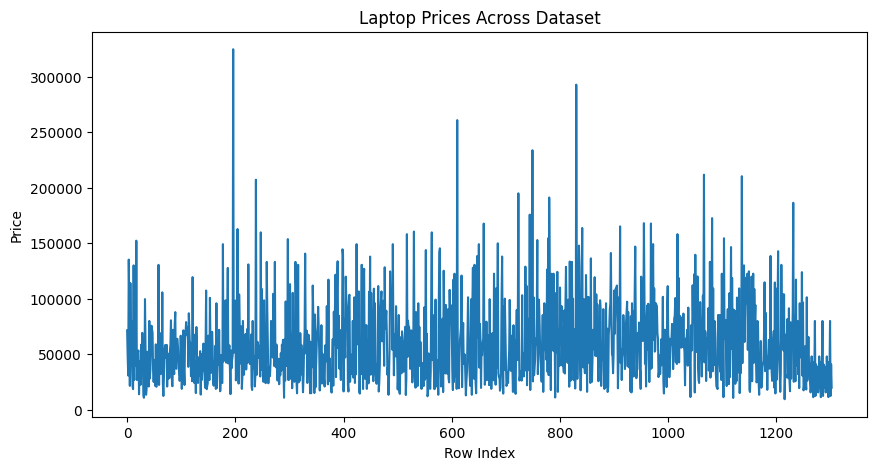

In [55]:
# Line Plot
plt.figure(figsize=(10, 5))

plt.plot(df.index, df["Price"])

plt.title("Laptop Prices Across Dataset")
plt.xlabel("Row Index")
plt.ylabel("Price")

plt.show()

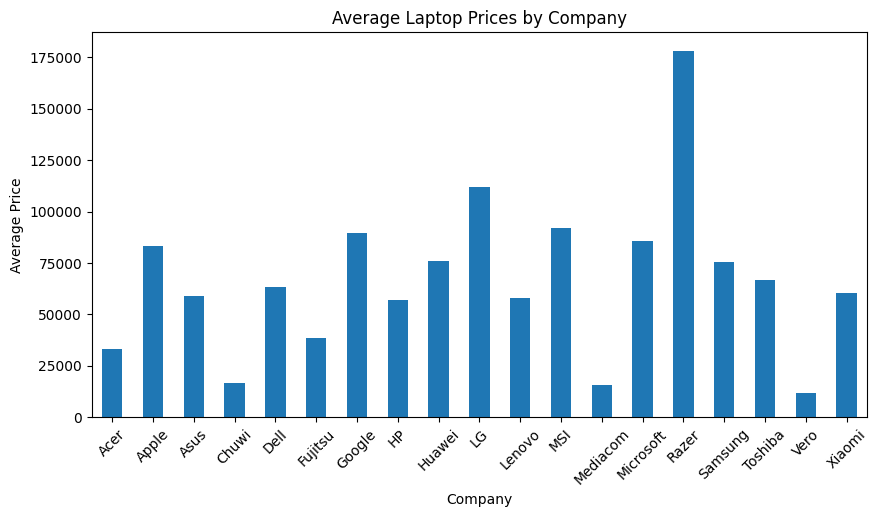

In [59]:
# Bar Chart
company_price = df.groupby("Company", observed=True)["Price"].mean()

plt.figure(figsize=(10, 5))

company_price.plot(kind="bar")

plt.title("Average Laptop Prices by Company")
plt.xlabel("Company")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

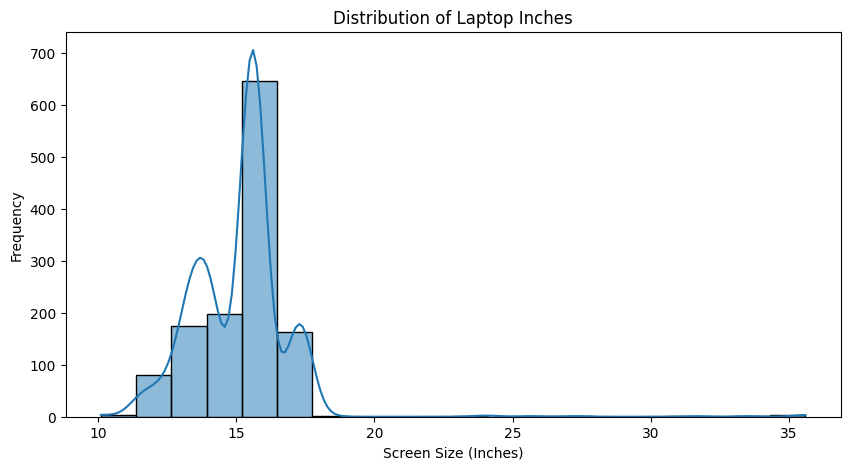

In [71]:
# Histogram
plt.figure(figsize=(10, 5))

sns.histplot(df["Inches"], bins=20, kde=True)

plt.title("Distribution of Laptop Inches")
plt.xlabel("Screen Size (Inches)")
plt.ylabel("Frequency")

plt.show()

In [73]:
df[["Ram", "Weight", "Price"]].corr() # Finding correlation to build Scatter Plot

,Ram,Weight,Price
Ram,1.000000,0.283306,0.685648
Weight,0.283306,1.000000,0.175900
Price,0.685648,0.175900,1.000000


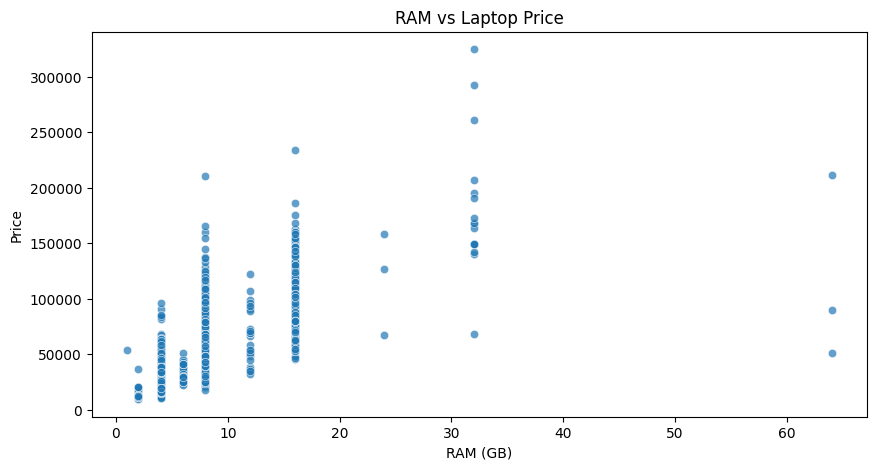

In [74]:
# Scatter Plot
plt.figure(figsize=(10, 5))

sns.scatterplot(x="Ram", y="Price", data=df, alpha=0.7)

plt.title("RAM vs Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")

plt.show()

plt.show()

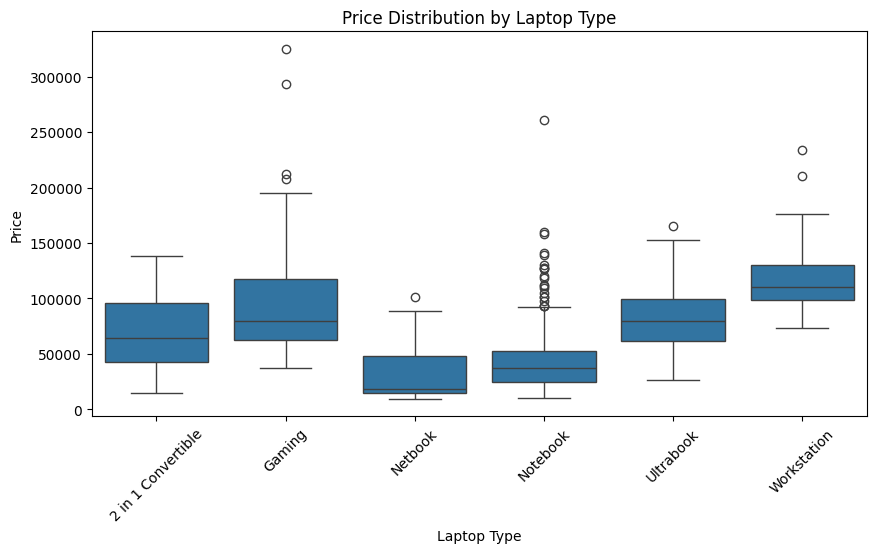

In [65]:
# Box Plot
plt.figure(figsize=(10, 5))

sns.boxplot(x="TypeName", y="Price", data=df)

plt.title("Price Distribution by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

# ==================================================
# Task 8: Correlation Heatmap
# ==================================================

##Correlation heat map: Compute the correlation matrix of all numeric columns using df.corr(). Visualize it with a heat map (use sns.heatmap() with annot=True). Identify the pair of variables with the highest absolute correlation.
##In the README, explain whether this correlation might indicate a causal relationship or whether a third variable could explain it, and name at least one plausible alternative explanation.

In [83]:
# Calculate Pearson correlation matrix
correlation_matrix = df.corr(numeric_only=True)

print("Pearson Correlation Matrix:")
display(correlation_matrix)

Pearson Correlation Matrix:


,Inches,Ram,Weight,Price
Inches,1.000000,0.142098,0.494708,0.044925
Ram,0.142098,1.000000,0.283306,0.685648
Weight,0.494708,0.283306,1.000000,0.175900
Price,0.044925,0.685648,0.175900,1.000000


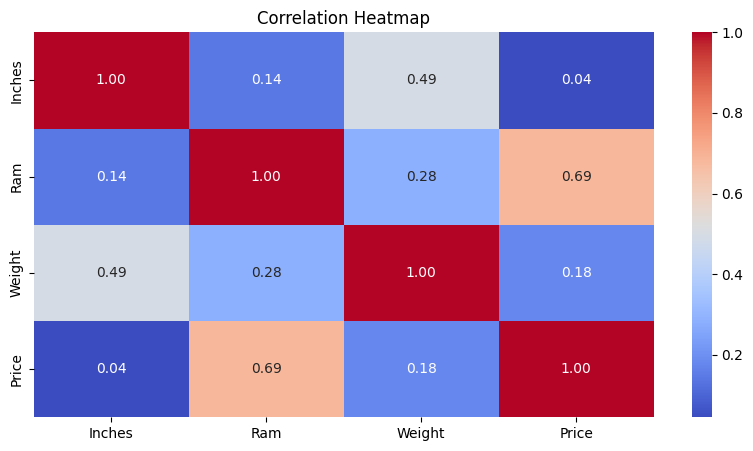

In [84]:
# Heatmap
plt.figure(figsize=(10, 5))

sns.heatmap(data=correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [90]:
# Find the pair with the highest absolute correlation
corr = correlation_matrix.abs()

# Remove self-correlation (1.0 on the diagonal)
np.fill_diagonal(corr.values, 0)

# Find strongest pair
highest_pair = corr.stack().idxmax()
highest_value = corr.stack().max()

print(f"Highest Correlated Pair: {highest_pair[0]} <-> {highest_pair[1]}")
print("Correlation:", round(highest_value, 4))

Highest Correlated Pair: Ram <-> Price
Correlation: 0.6856


# ==================================================
# Task 9a: Imputation Strategy Comparison
# ==================================================

##9(a). Imputation strategy comparison. For the two numeric columns with the highest absolute skewness identified in Task 5, compute both the column mean (df[col].mean()) and the column median (df[col].median()) before any imputation is applied to those columns. Print both values side by side for each column.
##In the README, state which statistic you chose for imputation and justify the choice based on the skewness direction: for a positively skewed column the mean is pulled upward by extreme high values, making the median a more representative central tendency; for a negatively skewed column the mean is pulled downward by extreme low values, again making the median more representative. Apply your chosen strategy using fillna() to any remaining nulls in those two columns and confirm with isnull().sum() that no nulls remain.

In [96]:
# Find the two numeric columns with the highest absolute skewness
top2_skewed = skewness.abs().sort_values(ascending=False).head(2).index

# Convert required columns in the original dataset to numeric
df_original["Inches"] = pd.to_numeric(df_original["Inches"], errors="coerce")

df_original["Ram"] = pd.to_numeric(
    df_original["Ram"].str.replace("GB", "", regex=False),
    errors="coerce"
)

In [98]:
# Compare Mean and Median
comparision = pd.DataFrame(columns=["Mean", "Median"])

for col in top2_skewed:
  comparision.loc[col] = [
      df_original[col].mean(),
      df_original[col].median()
  ]

print("Mean vs Median Comparision:")
display(comparision.round(2))

Mean vs Median Comparision:


,Mean,Median
Inches,15.13,15.6
Ram,8.46,8.0


In [100]:
# Verifying no remaining values remain
print("Remaining Missing Values:")

display(df[list(top2_skewed)].isnull().sum())

Remaining Missing Values:


,0
Inches,0
Ram,0


# ==================================================
# Task 9b: Spearman Rank Correlation
# ==================================================

##Compute the Pearson correlation matrix.
##Compute the Spearman correlation matrix.
##Compare them.
##Find the 3 column pairs where: ∣Spearman−Pearson∣ is the largest.

##Explain:
###Is the relationship monotonic but non-linear?
###Or approximately linear?
###Which correlation measure will you use in Part 2?

In [101]:
# Pearson correlation matrix
pearson_corr = df.corr(numeric_only=True)

print("Pearson Correlation Matrix:")
display(pearson_corr.round(2))

Pearson Correlation Matrix:


,Inches,Ram,Weight,Price
Inches,1.00,0.14,0.49,0.04
Ram,0.14,1.00,0.28,0.69
Weight,0.49,0.28,1.00,0.18
Price,0.04,0.69,0.18,1.00


In [102]:
# Spearman correlation matrix
spearman_corr = df.corr(method="spearman", numeric_only=True)

print("Spearman Correlation Matrix:")
display(spearman_corr.round(2))

Spearman Correlation Matrix:


,Inches,Ram,Weight,Price
Inches,1.00,0.14,0.85,-0.05
Ram,0.14,1.00,0.18,0.77
Weight,0.85,0.18,1.00,-0.02
Price,-0.05,0.77,-0.02,1.00


In [103]:
# Difference ∣Spearman−Pearson∣
difference = (spearman_corr - pearson_corr).abs()

print("Absolute Difference Matrix:")
display(difference.round(4))

Absolute Difference Matrix:


,Inches,Ram,Weight,Price
Inches,0.0000,0.0003,0.3581,0.0919
Ram,0.0003,0.0000,0.1037,0.0821
Weight,0.3581,0.1037,0.0000,0.1965
Price,0.0919,0.0821,0.1965,0.0000


In [104]:
# Unique Pairs
pairs = []

columns = difference.columns

for i in range(len(columns)):
  for j in range(i + 1, len(columns)):

    pairs.append({
        "Column 1": columns[i],
        "Column 2": columns[j],
        "Difference": difference.iloc[i, j]
    })

# Convert to DataFrame
difference_df = pd.DataFrame(pairs)

# Top 3 largest differences
top3 = difference_df.nlargest(3, "Difference")

print("Top 3 Column Pairs:")
display(top3)

Top 3 Column Pairs:


,Column 1,Column 2,Difference
1,Inches,Weight,0.358072
5,Weight,Price,0.196464
3,Ram,Weight,0.103734


In [106]:
pearson_corr.round(2)

,Inches,Ram,Weight,Price
Inches,1.00,0.14,0.49,0.04
Ram,0.14,1.00,0.28,0.69
Weight,0.49,0.28,1.00,0.18
Price,0.04,0.69,0.18,1.00


In [107]:
spearman_corr.round(2)

,Inches,Ram,Weight,Price
Inches,1.00,0.14,0.85,-0.05
Ram,0.14,1.00,0.18,0.77
Weight,0.85,0.18,1.00,-0.02
Price,-0.05,0.77,-0.02,1.00


# ==================================================
# Task 9c: Grouped Aggregation
# ==================================================

##Choose:

##One categorical column
##One numeric column

##Then compute: df.groupby(categorical_col)[numeric_col].agg(['mean', 'std', 'count'])

##Finally:

###Identify the group with the highest mean.
###Identify the group with the highest standard deviation.
###Compute the ratio of the highest mean to the lowest mean.
###State whether the categorical feature carries predictive signal.

In [109]:
# Group by Company and calculate mean, standard deviation and count of Price
group_stats = df.groupby("Company", observed=True)["Price"].agg(["mean", "std", "count"])

print("Grouped Aggregation:")
display(group_stats.round(2))

Grouped Aggregation:


,mean,std,count
Company,,,
Acer,33394.62,20015.77,103
Apple,83340.50,29923.31,21
Asus,58972.37,37406.11,156
Chuwi,16745.73,6216.33,3
Dell,63237.06,36155.22,287
Fujitsu,38574.72,5651.20,2
Google,89386.08,25217.00,3
HP,57214.37,33156.61,266
Huawei,75870.72,5651.20,2


In [110]:
# Highest Mean
highest_mean_group = group_stats["mean"].idxmax()

print("Group with Highest Mean:", highest_mean_group)
print("Mean Price:", round(group_stats.loc[highest_mean_group, "mean"], 2))

Group with Highest Mean: Razer
Mean Price: 178282.49


In [113]:
# Highest Standard Deviation
highest_std_group = group_stats["std"].idxmax()

print("Group with Highest Standard Deviation:", highest_std_group)
print("Standard Deviation:", round(group_stats.loc[highest_std_group, "std"], 2))

Group with Highest Standard Deviation: Razer
Standard Deviation: 99100.19


In [111]:
# Mean Ratio
highest_mean = group_stats["mean"].max()
lowest_mean = group_stats["mean"].min()

mean_ratio = highest_mean / lowest_mean

print("Highest Mean / Lowest Mean Ratio:", round(mean_ratio, 2))

Highest Mean / Lowest Mean Ratio: 15.39


In [112]:
# Predictive Signal
if mean_ratio > 2:
  print("The Company feature appears to carry predictive signal.")
else:
  print("The Company feature carries limited predictive signal.")

The Company feature appears to carry predictive signal.


# ==================================================
# Task 10: Save Cleaned Dataset
# ==================================================

##Save the clean dataset to a file named cleaned_data.csv using df.to_csv('cleaned_data.csv', index=False). This file will be loaded in Parts 2 and 3.

In [114]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv has been saved successfully!")

cleaned_data.csv has been saved successfully!
